In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

pd.set_option('display.max_columns', None)

import warnings

warnings.filterwarnings('ignore')

In [2]:
path_get3 = pd.read_csv("PARA_images_mean_score_greaterorequalthan_3_outier_removed.csv")
path_get2 = pd.read_csv("PARA_images_mean_score_greaterorequalthan_2_outier_removed.csv")

In [3]:
path_get3

,imageName,aestheticScore,qualityScore
0,iaa_pub10000_.jpg,3.020833,3.158333
1,iaa_pub10001_.jpg,3.270833,3.520833
2,iaa_pub10002_.jpg,2.875000,2.991667
3,iaa_pub10003_.jpg,3.562500,3.804167
4,iaa_pub10004_.jpg,3.020833,3.237500
...,...,...,...
31215,iaa_pub9998_.jpg,2.979167,3.166667
31216,iaa_pub9999_.jpg,3.416667,3.575000
31217,iaa_pub999_.jpg,2.740000,2.836000
31218,iaa_pub99_.jpg,3.580000,3.780000


In [4]:
path_get2

,imageName,aestheticScore,qualityScore
0,iaa_pub10000_.jpg,3.021739,3.169565
1,iaa_pub10001_.jpg,3.282609,3.547826
2,iaa_pub10002_.jpg,2.869565,2.995652
3,iaa_pub10003_.jpg,3.543478,3.800000
4,iaa_pub10004_.jpg,3.021739,3.252174
...,...,...,...
31215,iaa_pub9998_.jpg,2.978261,3.178261
31216,iaa_pub9999_.jpg,3.391304,3.560870
31217,iaa_pub999_.jpg,2.740000,2.836000
31218,iaa_pub99_.jpg,3.580000,3.780000


array([[<AxesSubplot:title={'center':'aestheticScore'}>,
        <AxesSubplot:title={'center':'qualityScore'}>]], dtype=object)

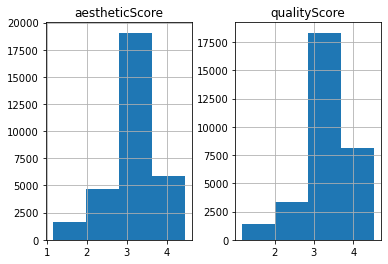

In [5]:
path_get2.hist(bins=4)

In [6]:
path_get2.describe()

,aestheticScore,qualityScore
count,31220.000000,31220.000000
mean,3.158553,3.327040
std,0.558106,0.560471
min,1.152174,1.170833
25%,2.900000,3.100000
50%,3.227273,3.422727
75%,3.541667,3.704348
max,4.458333,4.533333


array([[<AxesSubplot:title={'center':'aestheticScore'}>,
        <AxesSubplot:title={'center':'qualityScore'}>]], dtype=object)

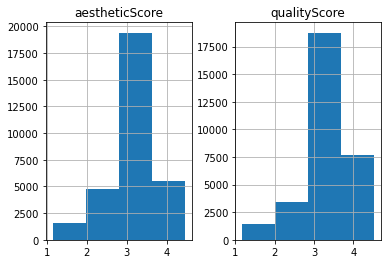

In [7]:
path_get3.hist(bins=4)

In [8]:
path_get3.describe()

,aestheticScore,qualityScore
count,31220.000000,31220.000000
mean,3.145592,3.312968
std,0.551070,0.553454
min,1.152174,1.168000
25%,2.895833,3.092000
50%,3.217391,3.410620
75%,3.520000,3.685185
max,4.458333,4.533333


## Get train_test dataset for Outliers >= 2 

In [9]:
minimum = np.amin(path_get2['aestheticScore'])
print(f'minimum value: {minimum:.4f}')

maximum = np.amax(path_get2['aestheticScore'])
print(f'maximum value: {maximum:.4f}')

minimum value: 1.1522
maximum value: 4.4583


In [19]:
from verstack.stratified_continuous_split import scsplit

X = path_get2['imageName']
y = path_get2['aestheticScore']

train, test = scsplit(path_get2, test_size=0.3, stratify=y, random_state=1234)
train

,imageName,aestheticScore,qualityScore
16322,iaa_pub24692_.jpg,2.956522,3.117391
9121,iaa_pub18210_.jpg,2.818182,2.977273
24090,iaa_pub3584_.jpg,2.913043,3.026087
12387,iaa_pub2114_.jpg,3.080000,3.020000
11984,iaa_pub20788_.jpg,3.456522,3.708696
...,...,...,...
9299,iaa_pub18371_.jpg,3.130435,3.365217
9279,iaa_pub18353_.jpg,2.891304,3.086957
15603,iaa_pub24044_.jpg,2.886364,3.086364
15726,iaa_pub24155_.jpg,2.420000,2.536000


array([[<AxesSubplot:title={'center':'aestheticScore'}>,
        <AxesSubplot:title={'center':'qualityScore'}>]], dtype=object)

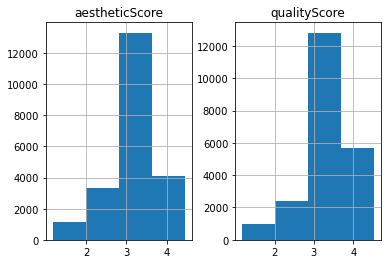

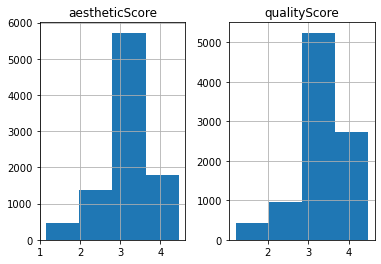

In [20]:
train.hist(bins=4)
test.hist(bins=4)

In [21]:
print(f'Training set size = {train.shape[0]}')
print(f'Test set size = {test.shape[0]}')
print(f'train/test ratio split: {test.shape[0]/train.shape[0]}')

Training set size = 21854
Test set size = 9366
train/test ratio split: 0.42857142857142855


In [22]:
train.reset_index(drop=True, inplace=True)
train

,imageName,aestheticScore,qualityScore
0,iaa_pub24692_.jpg,2.956522,3.117391
1,iaa_pub18210_.jpg,2.818182,2.977273
2,iaa_pub3584_.jpg,2.913043,3.026087
3,iaa_pub2114_.jpg,3.080000,3.020000
4,iaa_pub20788_.jpg,3.456522,3.708696
...,...,...,...
21849,iaa_pub18371_.jpg,3.130435,3.365217
21850,iaa_pub18353_.jpg,2.891304,3.086957
21851,iaa_pub24044_.jpg,2.886364,3.086364
21852,iaa_pub24155_.jpg,2.420000,2.536000


In [23]:
test.reset_index(drop=True, inplace=True)
test

,imageName,aestheticScore,qualityScore
0,iaa_pub21769_.jpg,3.318182,3.577273
1,iaa_pub30913_.jpg,2.880952,3.185714
2,iaa_pub3274_.jpg,3.440000,3.596000
3,iaa_pub6894_.jpg,3.040000,3.284000
4,iaa_pub26646_.jpg,2.978261,3.317391
...,...,...,...
9361,iaa_pub1477_.jpg,3.250000,3.479167
9362,iaa_pub25184_.jpg,2.568966,2.758621
9363,iaa_pub8525_.jpg,3.660000,3.948000
9364,iaa_pub30853_.jpg,3.476190,3.676190


In [24]:
# get training dataset with sessionId
para_images = pd.read_csv('PARA_001/annotation/PARA-Images.csv')
para_images = para_images[['sessionId', 'imageName']]

merged_train = pd.merge(para_images, train, on='imageName')

merged_train = merged_train.drop_duplicates(subset=["imageName"], keep='first')

merged_train.reset_index(drop=True, inplace=True)
merged_train


,sessionId,imageName,aestheticScore,qualityScore
0,session1,iaa_pub1_.jpg,3.809524,3.923810
1,session1,iaa_pub2_.jpg,3.142857,3.385714
2,session1,iaa_pub3_.jpg,2.928571,3.128571
3,session1,iaa_pub4_.jpg,3.428571,3.752381
4,session1,iaa_pub5_.jpg,3.214286,3.538095
...,...,...,...,...
21849,session99,iaa_pub6923_.jpg,3.000000,3.304000
21850,session99,iaa_pub6924_.jpg,2.760000,2.980000
21851,session99,iaa_pub6926_.jpg,3.180000,3.516000
21852,session99,iaa_pub6927_.jpg,3.660000,3.768000


In [25]:
# get testing dataset with sessionId
para_images = pd.read_csv('PARA_001/annotation/PARA-Images.csv')
para_images = para_images[['sessionId', 'imageName']]

merged_test = pd.merge(para_images, test, on='imageName')

merged_test = merged_test.drop_duplicates(subset=["imageName"], keep='first')

merged_test.reset_index(drop=True, inplace=True)
merged_test

,sessionId,imageName,aestheticScore,qualityScore
0,session1,iaa_pub6_.jpg,3.690476,3.890476
1,session1,iaa_pub7_.jpg,3.904762,4.052381
2,session1,iaa_pub11_.jpg,1.261905,1.395238
3,session1,iaa_pub13_.jpg,1.523810,1.638095
4,session1,iaa_pub16_.jpg,2.904762,3.157143
...,...,...,...,...
9361,session99,iaa_pub6921_.jpg,2.900000,3.116000
9362,session99,iaa_pub6922_.jpg,2.660000,2.876000
9363,session99,iaa_pub6925_.jpg,3.180000,3.396000
9364,session99,iaa_pub6928_.jpg,2.880000,3.052000


In [26]:
# Uncomment to produce train-test-split
train.to_csv('PARA_MTAIQ_GET2_train.csv', index=False)
test.to_csv('PARA_MTAIQ_GET2_test.csv', index=False)

## Get train_test dataset for Outliers >= 3

aestheticScore minimum value: 1.1522
aestheticScore maximum value: 4.4583
qualityScore minimum value: 1.1680
qualityScore maximum value: 4.5333
Training set size = 21854
Test set size = 9366
train/test ratio split: 0.42857142857142855


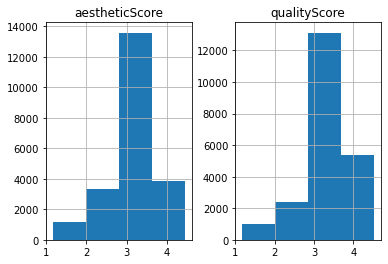

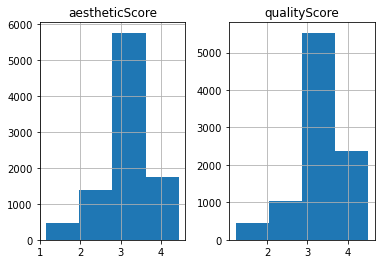

In [27]:
minimum = np.amin(path_get3['aestheticScore'])
print(f'aestheticScore minimum value: {minimum:.4f}')

maximum = np.amax(path_get3['aestheticScore'])
print(f'aestheticScore maximum value: {maximum:.4f}')

minimum = np.amin(path_get3['qualityScore'])
print(f'qualityScore minimum value: {minimum:.4f}')

maximum = np.amax(path_get3['qualityScore'])
print(f'qualityScore maximum value: {maximum:.4f}')


# train_test_split
X = path_get3['imageName']
y = path_get3['aestheticScore']

train, test = scsplit(path_get3, test_size=0.3, stratify=y, random_state=1234)
train.hist(bins=4)
test.hist(bins=4)

print(f'Training set size = {train.shape[0]}')
print(f'Test set size = {test.shape[0]}')
print(f'train/test ratio split: {test.shape[0]/train.shape[0]}')

In [28]:
train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

In [29]:
# get training dataset with sessionId
para_images = pd.read_csv('PARA_001/annotation/PARA-Images.csv')
para_images = para_images[['sessionId', 'imageName']]

merged_train = pd.merge(para_images, train, on='imageName')

merged_train = merged_train.drop_duplicates(subset=["imageName"], keep='first')

merged_train.reset_index(drop=True, inplace=True)
merged_train

,sessionId,imageName,aestheticScore,qualityScore
0,session1,iaa_pub2_.jpg,3.104167,3.341667
1,session1,iaa_pub5_.jpg,3.187500,3.491667
2,session1,iaa_pub6_.jpg,3.562500,3.866667
3,session1,iaa_pub9_.jpg,2.625000,2.904167
4,session1,iaa_pub10_.jpg,2.895833,3.158333
...,...,...,...,...
21849,session99,iaa_pub6924_.jpg,2.732143,2.960714
21850,session99,iaa_pub6926_.jpg,3.142857,3.492857
21851,session99,iaa_pub6927_.jpg,3.571429,3.710714
21852,session99,iaa_pub6929_.jpg,2.946429,3.178571


In [30]:
# get testing dataset with sessionId
para_images = pd.read_csv('PARA_001/annotation/PARA-Images.csv')
para_images = para_images[['sessionId', 'imageName']]

merged_test = pd.merge(para_images, test, on='imageName')

merged_test = merged_test.drop_duplicates(subset=["imageName"], keep='first')

merged_test.reset_index(drop=True, inplace=True)
merged_test

,sessionId,imageName,aestheticScore,qualityScore
0,session1,iaa_pub1_.jpg,3.750000,3.866667
1,session1,iaa_pub3_.jpg,2.916667,3.104167
2,session1,iaa_pub4_.jpg,3.416667,3.716667
3,session1,iaa_pub7_.jpg,3.812500,3.962500
4,session1,iaa_pub8_.jpg,2.895833,3.154167
...,...,...,...,...
9361,session99,iaa_pub6915_.jpg,3.053571,3.282143
9362,session99,iaa_pub6922_.jpg,2.553571,2.785714
9363,session99,iaa_pub6923_.jpg,2.982143,3.289286
9364,session99,iaa_pub6925_.jpg,3.125000,3.357143


In [31]:
train.to_csv('PARA_MTAIQ_GET3_train.csv', index=False)
test.to_csv('PARA_MTAIQ_GET3_test.csv', index=False)